# Multi-Channel CNN for Cortical Layer Classification

This notebook trains a 1-D convolutional neural network that classifies V1 excitatory neurons into cortical layers (L2/3, L4, L5, L6) using **multi-channel time-series inputs**.

Each sample is a tensor of shape `(C, T)` where `T` is the shared time axis and `C = 12` channels:

| Channel | Source | Description |
|---|---|---|
| 0 | Neural response | Z-scored calcium/voltage trace |
| 1 | Stimulus | Per-frame mean luminance (`stim_mean`) |
| 2 | Stimulus | Per-frame pixel std / contrast (`stim_std`) |
| 3 | Stimulus | Frame-to-frame motion energy (`stim_motion`) |
| 4 | Stimulus | Spatial gradient energy (`stim_grad`) |
| 5 | Stimulus | High-gradient edge fraction (`stim_edge_frac`) |
| 6 | Stimulus | Centre-surround contrast (`stim_center_surround`) |
| 7 | Stimulus | Normalised contrast (`stim_norm_contrast`) |
| 8 | Behaviour | Treadmill velocity |
| 9 | Behaviour | Pupil x-position |
| 10 | Behaviour | Pupil y-position |
| 11 | Behaviour | Pupil size |

The pipeline follows the same procedure as `CNN classification2.ipynb`:
neurons are split train/test **by identity** (not by trial) to prevent leakage,
and per-neuron majority-vote across trials is reported alongside trial-level metrics.

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
import os
import warnings
import importlib
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

import microns_datacleaner as mic
import microns_datacleaner.filters as fl

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Locate workspace root ─────────────────────────────────────────────────────
def _find_root():
    p = Path.cwd()
    while p != p.parent:
        if (p / 'microns.h5').exists():
            return p
        p = p.parent
    # fallback: walk up looking for data/1718/raw
    p = Path.cwd()
    while p != p.parent:
        if (p / 'data' / '1718' / 'raw').exists():
            return p
        p = p.parent
    raise RuntimeError('Cannot find workspace root.')

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# reader.py lives in tommy/
TOMMY_DIR = Path(__file__).parent if '__file__' in dir() else Path('..').resolve()
if str(TOMMY_DIR) not in sys.path:
    sys.path.insert(0, str(TOMMY_DIR))

print(f'Workspace root: {ROOT}')

Workspace root: c:\Users\tomma\Desktop\NEUROSCIENCE


In [18]:
# ── Load structural metadata ──────────────────────────────────────────────────
cleaner = mic.MicronsDataCleaner(
    datadir=os.path.relpath(str(ROOT / 'data')),
    version=1718,
    download_policy='minimum',
)
units_match, _ = cleaner.process_nucleus_data(functional_data='match')

matched = fl.filter_neurons(
    units_match,
    tuning='matched',
    cell_type='excitatory_neuron',
    brain_area='V1',
).copy()

unit_id_col = None
for col_name in ['functional_unit_id', 'unit_id', 'index', 'neuron_idx', 'neuron_id']:
    if col_name in matched.columns:
        unit_id_col = col_name
        break

if unit_id_col is None:
    raise ValueError(f'No usable neuron index column. Available: {list(matched.columns)}')

print(f'Matched neurons: {len(matched)}')
print(f'Unit id column: {unit_id_col}')
print(matched['layer'].value_counts(dropna=False).sort_index().to_string())

Transform positions: 100%|██████████| 94014/94014 [00:01<00:00, 60244.96it/s]


Matched neurons: 13044
Unit id column: functional_unit_id
layer
L1        16
L2/3    6340
L4      3941
L5      2269
L6       478


In [3]:
from reader import MicronsReader

H5_CANDIDATES = [
    ROOT / 'microns.h5',
    ROOT / 'data' / 'functional' / 'microns_functional.h5',
    ROOT / 'data' / 'functional' / 'microns_functional.h5.h5',
]
functional_path = next((p for p in H5_CANDIDATES if p.exists()), None)
if functional_path is None:
    raise FileNotFoundError(f'No functional H5 found. Tried: {H5_CANDIDATES}')

print(f'Using functional file: {functional_path}')
funcreader   = MicronsReader(str(functional_path))
session_keys = list(funcreader.f['sessions'].keys())

scan_rows = []
for k in session_keys:
    parts = k.split('_')
    if len(parts) == 2:
        try:
            scan_rows.append((int(parts[0]), int(parts[1]), k))
        except ValueError:
            pass

scan_df = (
    pd.DataFrame(scan_rows, columns=['session', 'scan_idx', 'key'])
    .sort_values(['session', 'scan_idx'])
    .reset_index(drop=True)
)
print(f'Session/scan keys available: {len(scan_df)}')

Using functional file: c:\Users\tomma\Desktop\NEUROSCIENCE\microns.h5
Session/scan keys available: 14


In [4]:
# ── Helper functions ──────────────────────────────────────────────────────────

def zscore_1d(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    m = np.nanmean(x)
    s = np.nanstd(x)
    if not np.isfinite(s) or s < eps:
        return np.zeros_like(x)
    return (x - m) / (s + eps)


def resample_to(arr: np.ndarray, target_len: int) -> np.ndarray:
    """Linearly resample a 1-D array to exactly target_len points."""
    arr = np.asarray(arr, dtype=np.float32).ravel()
    if arr.size == target_len:
        return arr
    old_idx = np.linspace(0, 1, arr.size)
    new_idx = np.linspace(0, 1, target_len)
    return np.interp(new_idx, old_idx, arr).astype(np.float32)


def extract_stim_channels(clip: np.ndarray, target_len: int) -> np.ndarray:
    """
    Extract 7 per-frame stimulus feature time series from a (F, H, W) clip
    and resample each to target_len.
    Returns array of shape (7, target_len), each row z-scored.
    """
    frames = clip.astype(np.float32)
    if frames.ndim != 3:
        return np.zeros((7, target_len), dtype=np.float32)
    F, H, W = frames.shape
    eps = 1e-8

    pix = frames.reshape(F, -1)
    mean_intensity = pix.mean(axis=1)
    std_intensity  = pix.std(axis=1)

    if F > 1:
        d = np.abs(np.diff(frames, axis=0))
        motion_energy = np.concatenate([[0.0], d.reshape(F - 1, -1).mean(axis=1)])
    else:
        motion_energy = np.zeros(F, dtype=np.float32)

    grad_energy  = np.zeros(F, dtype=np.float32)
    edge_fraction = np.zeros(F, dtype=np.float32)
    for i in range(F):
        gy, gx = np.gradient(frames[i])
        gm = np.sqrt(gx * gx + gy * gy)
        grad_energy[i]  = gm.mean()
        thr = np.percentile(gm, 85)
        edge_fraction[i] = (gm > thr).mean()

    h0, h1 = H // 4, (3 * H) // 4
    w0, w1 = W // 4, (3 * W) // 4
    center = frames[:, h0:h1, w0:w1]
    center_mean  = center.reshape(F, -1).mean(axis=1)
    surround_sum = pix.sum(axis=1) - center.reshape(F, -1).sum(axis=1)
    surround_n   = (H * W) - ((h1 - h0) * (w1 - w0))
    surround_mean = surround_sum / max(surround_n, 1)
    center_surround = center_mean - surround_mean

    norm_contrast = std_intensity / (mean_intensity + eps)

    raw_channels = [
        mean_intensity, std_intensity, motion_energy,
        grad_energy, edge_fraction, center_surround, norm_contrast,
    ]
    result = np.zeros((7, target_len), dtype=np.float32)
    for i, ch in enumerate(raw_channels):
        resampled = resample_to(ch, target_len)
        result[i] = zscore_1d(resampled)
    return result


def extract_behaviour_channels(trial: dict, target_len: int) -> np.ndarray:
    """
    Extract treadmill + pupil channels from a trial dict.
    Returns array of shape (4, target_len): [treadmill, pupil_x, pupil_y, pupil_size].
    NaN values are filled with zero after z-scoring.
    """
    result = np.zeros((4, target_len), dtype=np.float32)

    # ── Treadmill ─────────────────────────────────────────────────────────────
    treadmill = np.asarray(trial['treadmill'], dtype=np.float32).ravel()
    treadmill = np.where(np.isfinite(treadmill), treadmill, 0.0)
    result[0] = zscore_1d(resample_to(treadmill, target_len))

    # ── Pupil ─────────────────────────────────────────────────────────────────
    pupil = np.asarray(trial['pupil'], dtype=np.float32)
    # Pupil can be (T, 3) or (3, T); normalise to (3, T)
    if pupil.ndim == 2:
        if pupil.shape[0] == 3 and pupil.shape[1] != 3:
            pass  # already (3, T)
        elif pupil.shape[1] == 3:
            pupil = pupil.T  # (T, 3) → (3, T)
        # If neither dim is 3, fall through and leave zeros
        if pupil.shape[0] >= 3:
            for i in range(3):
                ch = np.where(np.isfinite(pupil[i]), pupil[i], np.nan)
                ch = np.where(np.isfinite(ch), ch, 0.0)
                result[1 + i] = zscore_1d(resample_to(ch, target_len))
    elif pupil.ndim == 1 and pupil.size > 0:
        # Single-column pupil (size only)
        ch = np.where(np.isfinite(pupil), pupil, 0.0)
        result[3] = zscore_1d(resample_to(ch, target_len))  # put in size channel

    return result

In [19]:
# ── Data collection (ONE sample per matched neuron) ─────────────────────────────
MAX_TRIALS_PER_SCAN = 8
MIN_TRACE_LEN       = 60
TARGET_LEN          = 300
EXCLUDE_LAYERS      = {'L1'}

# N_CHANNELS = 1 (neural) + 7 (stimulus) + 4 (behaviour)
N_CHANNELS = 12

STIM_CHANNEL_NAMES = [
    'stim_mean', 'stim_std', 'stim_motion',
    'stim_grad', 'stim_edge_frac', 'stim_center_surround', 'stim_norm_contrast',
]
BEH_CHANNEL_NAMES = ['treadmill', 'pupil_x', 'pupil_y', 'pupil_size']
CHANNEL_NAMES = ['neural_response'] + STIM_CHANNEL_NAMES + BEH_CHANNEL_NAMES

# Use target_id as the neuron identity when available so each structural neuron
# contributes exactly one sample in the final dataset.
neuron_key_col = 'target_id' if 'target_id' in matched.columns else unit_id_col
print(f'Neuron identity column used for one-sample policy: {neuron_key_col}')

# Collect one sample per neuron key.
neuron_records = {}  # neuron_key -> record
clip_cache  = {}     # cond_hash -> stim_channels (7, TARGET_LEN) or None

matched_scans = matched[['session', 'scan_idx']].dropna().drop_duplicates().copy()
matched_scans['session']  = matched_scans['session'].astype(int)
matched_scans['scan_idx'] = matched_scans['scan_idx'].astype(int)

scan_candidates = (
    scan_df.merge(matched_scans, on=['session', 'scan_idx'], how='inner')
    .sort_values(['session', 'scan_idx'])
    .reset_index(drop=True)
)
print(f'Candidate session/scan pairs: {len(scan_candidates)}')

for _, srow in scan_candidates.iterrows():
    session  = int(srow['session'])
    scan_idx = int(srow['scan_idx'])
    key      = srow['key']

    session_neurons = matched[
        (matched['session'] == session) & (matched['scan_idx'] == scan_idx)
    ].copy()
    session_neurons = session_neurons.dropna(subset=[unit_id_col, 'layer', neuron_key_col])
    session_neurons['layer'] = session_neurons['layer'].astype(str)
    session_neurons = session_neurons[~session_neurons['layer'].isin(EXCLUDE_LAYERS)]
    if session_neurons.empty:
        continue

    hashes = funcreader.get_hashes_by_session(key)
    if len(hashes) == 0:
        continue

    unit_ids       = funcreader.f[f'sessions/{key}/meta/unit_ids'][:]
    unit_id_to_row = {int(u): idx for idx, u in enumerate(unit_ids)}
    n_trials       = min(len(hashes), MAX_TRIALS_PER_SCAN)

    for t in range(n_trials):
        try:
            td = funcreader.get_trial(key, t)
        except (ValueError, KeyError):
            continue
        if td is None:
            continue

        cond_hash = hashes[t]
        if cond_hash not in clip_cache:
            clip, _ = funcreader.get_video_data(cond_hash)
            if clip is None:
                clip_cache[cond_hash] = None
            else:
                clip_cache[cond_hash] = extract_stim_channels(clip, TARGET_LEN)

        stim_channels = clip_cache[cond_hash]  # (7, TARGET_LEN) or None
        beh_channels  = extract_behaviour_channels(td, TARGET_LEN)  # (4, TARGET_LEN)
        responses     = td['responses']

        for _, nr in session_neurons.iterrows():
            neuron_key = int(nr[neuron_key_col])
            if neuron_key in neuron_records:
                continue  # one sample per neuron

            layer = str(nr['layer'])
            fuid  = int(nr[unit_id_col])
            row_idx = unit_id_to_row.get(fuid)
            if row_idx is None or row_idx >= responses.shape[0]:
                continue

            trace = np.asarray(responses[row_idx, :], dtype=np.float32).ravel()
            trace = trace[np.isfinite(trace)]
            if trace.size < MIN_TRACE_LEN:
                continue

            # Trim/pad neural trace to TARGET_LEN.
            trace = resample_to(trace, TARGET_LEN)
            trace = zscore_1d(trace)

            # Build multi-channel array (N_CHANNELS, TARGET_LEN).
            multichan = np.zeros((N_CHANNELS, TARGET_LEN), dtype=np.float32)
            multichan[0] = trace
            if stim_channels is not None:
                multichan[1:8] = stim_channels
            multichan[8:12] = beh_channels

            neuron_records[neuron_key] = {
                'neuron_key': neuron_key,
                'layer':      layer,
                'multichan':  multichan,
                'unit_id':    fuid,
                'session':    session,
                'scan_idx':   scan_idx,
                'trial_idx':  t,
            }

records = list(neuron_records.values())
print(f'Total unique neuron samples collected: {len(records)}')
print('Samples by layer:')
print(pd.Series([r['layer'] for r in records]).value_counts().sort_index().to_string())

Neuron identity column used for one-sample policy: functional_unit_id
Candidate session/scan pairs: 14
Total unique neuron samples collected: 6548
Samples by layer:
L2/3    2704
L4      2072
L5      1425
L6       347


In [20]:
# ── Split neurons train / test (one sample per neuron, ~6k train target) ─────────
neuron_df = pd.DataFrame([
    {'neuron_key': r['neuron_key'], 'layer': r['layer']} for r in records
]).drop_duplicates(subset=['neuron_key'])

layer_counts = neuron_df['layer'].value_counts()
keep_layers  = layer_counts[layer_counts >= 20].index.tolist()
neuron_df    = neuron_df[neuron_df['layer'].isin(keep_layers)].copy()
print('Neurons per layer (after rare-class filter):')
print(neuron_df['layer'].value_counts().sort_index().to_string())

# Target approximately 6k train samples with a 75/25 split.
# total_needed ~= 6000 / 0.75 = 8000 total neurons.
TARGET_TRAIN_SAMPLES = 6000
test_size = 0.25
total_target = int(round(TARGET_TRAIN_SAMPLES / (1 - test_size)))

if len(neuron_df) > total_target:
    # Stratified downsample to keep class balance while matching the desired scale.
    _, neuron_df = train_test_split(
        neuron_df,
        train_size=total_target,
        random_state=42,
        stratify=neuron_df['layer'].values,
    )
    neuron_df = neuron_df.reset_index(drop=True)

print(f"Total neurons used: {len(neuron_df)} (target total: {total_target})")

train_neurons, test_neurons = train_test_split(
    neuron_df['neuron_key'].values,
    test_size=test_size,
    random_state=42,
    stratify=neuron_df['layer'].values,
)
train_set = set(train_neurons)
test_set  = set(test_neurons)
print(f'Train neurons/samples: {len(train_set)} | Test neurons/samples: {len(test_set)}')

enc = LabelEncoder()
enc.fit(neuron_df['layer'])


def build_split(neuron_keys_set):
    X, y, uids = [], [], []
    for r in records:
        if r['neuron_key'] not in neuron_keys_set or r['layer'] not in keep_layers:
            continue
        X.append(r['multichan'])            # (N_CHANNELS, TARGET_LEN)
        y.append(r['layer'])
        uids.append(r['neuron_key'])
    return np.asarray(X, dtype=np.float32), enc.transform(y), np.array(uids)


X_train, y_train, uids_train = build_split(train_set)
X_test,  y_test,  uids_test  = build_split(test_set)

print(f'\nTrain samples: {X_train.shape} | Test samples: {X_test.shape}')
print(f'Input shape per sample: channels={X_train.shape[1]}, time={X_train.shape[2]}')
print('Train class distribution:')
print(pd.Series(enc.inverse_transform(y_train)).value_counts().sort_index().to_string())
print('Test class distribution:')
print(pd.Series(enc.inverse_transform(y_test)).value_counts().sort_index().to_string())

Neurons per layer (after rare-class filter):
layer
L2/3    2704
L4      2072
L5      1425
L6       347
Total neurons used: 6548 (target total: 8000)
Train neurons/samples: 4911 | Test neurons/samples: 1637

Train samples: (4911, 12, 300) | Test samples: (1637, 12, 300)
Input shape per sample: channels=12, time=300
Train class distribution:
L2/3    2028
L4      1554
L5      1069
L6       260
Test class distribution:
L2/3    676
L4      518
L5      356
L6       87


In [21]:
# ── PyTorch setup ─────────────────────────────────────────────────────────────
if importlib.util.find_spec('torch') is None:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '--quiet', 'torch',
        '--index-url', 'https://download.pytorch.org/whl/cpu',
    ])

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device: {DEVICE}')

n_classes    = len(enc.classes_)
class_counts = np.bincount(y_train, minlength=n_classes).astype(np.float32)
class_weights = torch.tensor(1.0 / (class_counts + 1e-8)).to(DEVICE)
class_weights /= class_weights.sum()

BATCH_SIZE = 128

def make_loader(X, y, shuffle):
    # X already has shape (B, C, T)
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(Xt, yt), batch_size=BATCH_SIZE, shuffle=shuffle, drop_last=False)

train_loader = make_loader(X_train, y_train, shuffle=True)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

PyTorch 2.11.0+cpu | device: cpu
Train batches: 39 | Test batches: 13


In [22]:
# ── Multi-channel CNN architectures ──────────────────────────────────────────

class MultiChannelShallowCNN(nn.Module):
    """
    Shallow 1-D CNN for multi-channel input.
    Input shape: (B, C, T) where C = N_CHANNELS, T = TARGET_LEN.

    Architecture:
      Block 1: Conv1d(C  →  64, k=7) → BN → ReLU → MaxPool(2)
      Block 2: Conv1d(64 → 128, k=5) → BN → ReLU → MaxPool(2)
      Block 3: Conv1d(128→ 256, k=3) → BN → ReLU → MaxPool(2)
      Head:    Flatten → Linear(256·T/8, 256) → ReLU → Dropout → Linear → n_classes
    """
    def __init__(self, in_channels: int, seq_len: int, n_classes: int, dropout: float = 0.4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, 64,  kernel_size=7, padding=3), nn.BatchNorm1d(64),  nn.ReLU(True), nn.MaxPool1d(2),
            nn.Conv1d(64,         128,  kernel_size=5, padding=2), nn.BatchNorm1d(128), nn.ReLU(True), nn.MaxPool1d(2),
            nn.Conv1d(128,        256,  kernel_size=3, padding=1), nn.BatchNorm1d(256), nn.ReLU(True), nn.MaxPool1d(2),
        )
        flat = 256 * (seq_len // 8)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat, 256), nn.ReLU(True), nn.Dropout(dropout),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):   # x: (B, C, T)
        return self.head(self.conv(x))


class ResBlock1d(nn.Module):
    """1-D residual block: two Conv layers with a skip connection."""
    def __init__(self, channels: int, kernel_size: int = 3):
        super().__init__()
        pad = kernel_size // 2
        self.net = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=pad, bias=False),
            nn.BatchNorm1d(channels), nn.ReLU(True),
            nn.Conv1d(channels, channels, kernel_size, padding=pad, bias=False),
            nn.BatchNorm1d(channels),
        )
        self.act = nn.ReLU(True)

    def forward(self, x):
        return self.act(self.net(x) + x)


class MultiChannelResidualCNN(nn.Module):
    """
    Residual 1-D CNN for multi-channel input.
    Input shape: (B, C, T).

    Architecture:
      Stem:   Conv1d(C → 64, k=7) → BN → ReLU
      Stage 1: ResBlock(64) → Conv1d(64→128, stride=2) → BN → ReLU
      Stage 2: ResBlock(128)→ Conv1d(128→256, stride=2)→ BN → ReLU
      Stage 3: ResBlock(256)
      Head:   AdaptiveAvgPool → Flatten → Dropout → FC(256→128) → ReLU → Dropout → FC → n_classes
    """
    def __init__(self, in_channels: int, seq_len: int, n_classes: int, dropout: float = 0.4):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(True),
        )
        self.stage1 = nn.Sequential(
            ResBlock1d(64),
            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm1d(128), nn.ReLU(True),
        )
        self.stage2 = nn.Sequential(
            ResBlock1d(128),
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm1d(256), nn.ReLU(True),
        )
        self.stage3 = nn.Sequential(ResBlock1d(256))
        self.pool   = nn.AdaptiveAvgPool1d(1)
        self.head   = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128), nn.ReLU(True),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x)
        return self.head(x)


def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

shallow_cnn  = MultiChannelShallowCNN(N_CHANNELS, TARGET_LEN, n_classes).to(DEVICE)
residual_cnn = MultiChannelResidualCNN(N_CHANNELS, TARGET_LEN, n_classes).to(DEVICE)

print(f'MultiChannelShallowCNN  params: {count_params(shallow_cnn):,}')
print(f'MultiChannelResidualCNN params: {count_params(residual_cnn):,}')
print(f'Input shape: (batch, {N_CHANNELS}, {TARGET_LEN})')
print(f'Channels: {CHANNEL_NAMES}')

MultiChannelShallowCNN  params: 2,572,100
MultiChannelResidualCNN params: 680,452
Input shape: (batch, 12, 300)
Channels: ['neural_response', 'stim_mean', 'stim_std', 'stim_motion', 'stim_grad', 'stim_edge_frac', 'stim_center_surround', 'stim_norm_contrast', 'treadmill', 'pupil_x', 'pupil_y', 'pupil_size']


In [23]:
# ── Training utilities ────────────────────────────────────────────────────────
def train_model(model, train_loader, test_loader, *,
                lr=3e-4, weight_decay=1e-4,
                max_epochs=150, patience=15,
                label='model'):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=max_epochs)

    history      = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state    = None
    patience_cnt  = 0

    for epoch in range(1, max_epochs + 1):
        # train
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimiser.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimiser.step()
            running_loss += loss.item() * xb.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        # validate
        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits   = model(xb)
                val_loss += criterion(logits, yb).item() * xb.size(0)
                correct  += (logits.argmax(1) == yb).sum().item()
        val_loss /= len(test_loader.dataset)
        val_acc   = correct / len(test_loader.dataset)

        scheduler.step()
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt  = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f'[{label}] Early stop at epoch {epoch}')
                break

        if epoch % 1 == 0 or epoch == 1:
            print(f'[{label}] Epoch {epoch:3d} | train={train_loss:.4f}  val={val_loss:.4f}  acc={val_acc:.3f}')

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    print(f'[{label}] Restored best checkpoint (val_loss={best_val_loss:.4f})')
    return history


def evaluate(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
    return np.concatenate(preds)

In [24]:
# ── Train ShallowCNN ──────────────────────────────────────────────────────────
shallow_cnn = MultiChannelShallowCNN(N_CHANNELS, TARGET_LEN, n_classes).to(DEVICE)
history_shallow = train_model(shallow_cnn, train_loader, test_loader, label='ShallowCNN')

[ShallowCNN] Epoch   1 | train=1.3248  val=1.1137  acc=0.414
[ShallowCNN] Epoch   2 | train=1.1778  val=1.0951  acc=0.352
[ShallowCNN] Epoch   3 | train=1.1648  val=1.0854  acc=0.404
[ShallowCNN] Epoch   4 | train=1.1483  val=1.0763  acc=0.373
[ShallowCNN] Epoch   5 | train=1.1231  val=1.0731  acc=0.378
[ShallowCNN] Epoch   6 | train=1.1162  val=1.0630  acc=0.407
[ShallowCNN] Epoch   7 | train=1.0905  val=1.0581  acc=0.378
[ShallowCNN] Epoch   8 | train=1.0722  val=1.0615  acc=0.432
[ShallowCNN] Epoch   9 | train=1.0540  val=1.0396  acc=0.432
[ShallowCNN] Epoch  10 | train=1.0112  val=1.0160  acc=0.440
[ShallowCNN] Epoch  11 | train=0.9672  val=0.9672  acc=0.464
[ShallowCNN] Epoch  12 | train=0.8908  val=0.8970  acc=0.502
[ShallowCNN] Epoch  13 | train=0.8087  val=0.8244  acc=0.580
[ShallowCNN] Epoch  14 | train=0.7488  val=0.7495  acc=0.650
[ShallowCNN] Epoch  15 | train=0.6556  val=0.7176  acc=0.681
[ShallowCNN] Epoch  16 | train=0.6173  val=0.6645  acc=0.721
[ShallowCNN] Epoch  17 |

In [25]:
# ── Train ResidualCNN ─────────────────────────────────────────────────────────
residual_cnn = MultiChannelResidualCNN(N_CHANNELS, TARGET_LEN, n_classes).to(DEVICE)
history_res  = train_model(residual_cnn, train_loader, test_loader, label='ResidualCNN')

[ResidualCNN] Epoch   1 | train=1.2643  val=1.1354  acc=0.360
[ResidualCNN] Epoch   2 | train=1.1882  val=1.1068  acc=0.395
[ResidualCNN] Epoch   3 | train=1.1720  val=1.0831  acc=0.411
[ResidualCNN] Epoch   4 | train=1.1377  val=1.0954  acc=0.400
[ResidualCNN] Epoch   5 | train=1.1354  val=1.2086  acc=0.491
[ResidualCNN] Epoch   6 | train=1.1195  val=1.1320  acc=0.324
[ResidualCNN] Epoch   7 | train=1.1170  val=1.0946  acc=0.422
[ResidualCNN] Epoch   8 | train=1.0949  val=1.0890  acc=0.343
[ResidualCNN] Epoch   9 | train=1.0800  val=1.0844  acc=0.346
[ResidualCNN] Epoch  10 | train=1.0535  val=1.0768  acc=0.406
[ResidualCNN] Epoch  11 | train=1.0009  val=1.1296  acc=0.371
[ResidualCNN] Epoch  12 | train=0.9465  val=1.2083  acc=0.335
[ResidualCNN] Epoch  13 | train=0.8624  val=1.3482  acc=0.495
[ResidualCNN] Epoch  14 | train=0.7891  val=1.0857  acc=0.565
[ResidualCNN] Epoch  15 | train=0.6845  val=1.1859  acc=0.441
[ResidualCNN] Epoch  16 | train=0.6236  val=0.9512  acc=0.619
[Residua

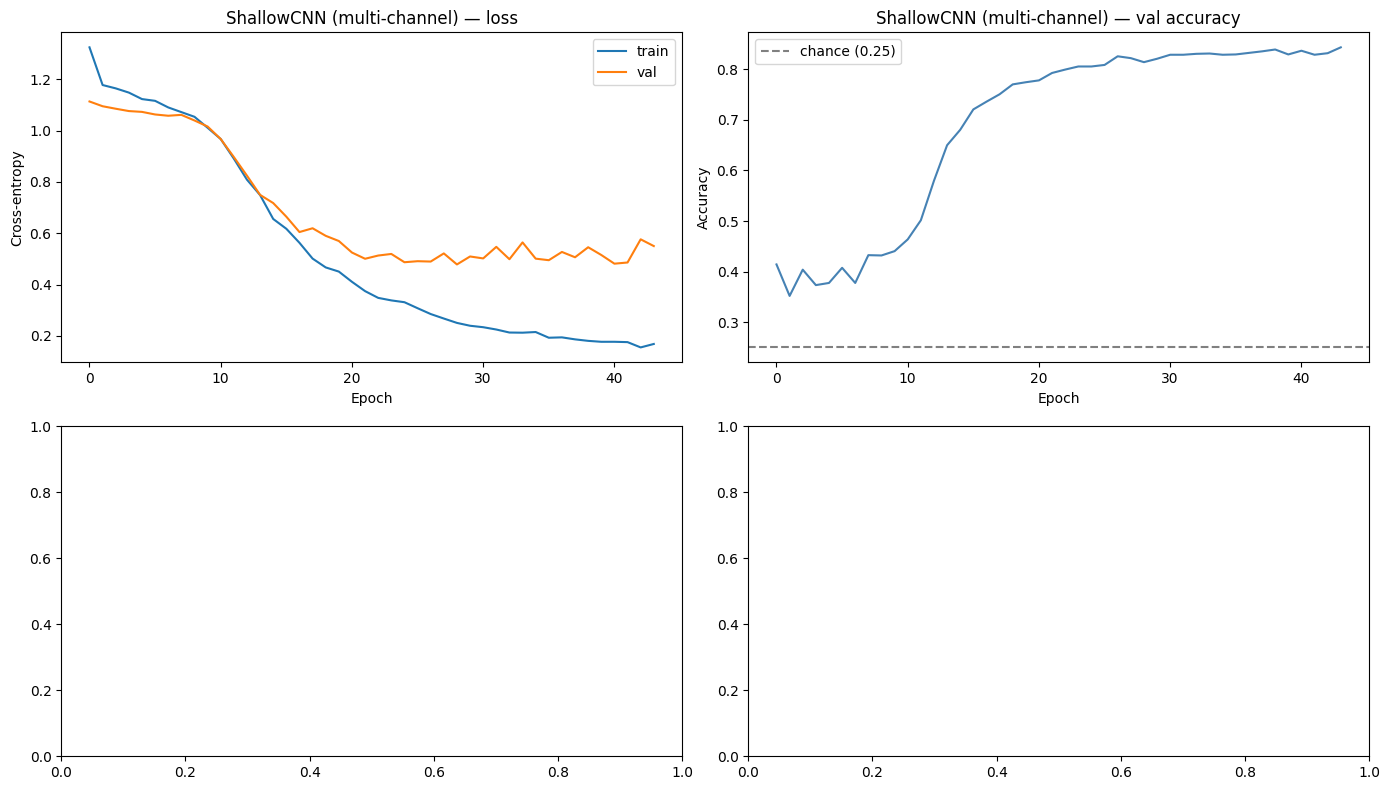

In [26]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, (hist, name) in enumerate([
    (history_shallow, 'ShallowCNN (multi-channel)'),
    #(history_res,     'ResidualCNN (multi-channel)'),
]):
    ax_loss, ax_acc = axes[row]
    ax_loss.plot(hist['train_loss'], label='train')
    ax_loss.plot(hist['val_loss'],   label='val')
    ax_loss.set_title(f'{name} — loss')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Cross-entropy')
    ax_loss.legend()

    ax_acc.plot(hist['val_acc'], color='steelblue')
    ax_acc.axhline(1 / n_classes, color='grey', linestyle='--', label=f'chance ({1/n_classes:.2f})')
    ax_acc.set_title(f'{name} — val accuracy')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()

plt.tight_layout()
plt.show()

In [29]:
# ── Trial-level evaluation ────────────────────────────────────────────────────
eval_results = []

for model, name in [
    (shallow_cnn,  'ShallowCNN (multi-channel)'),
    (residual_cnn, 'ResidualCNN (multi-channel)'),
]:
    y_pred = evaluate(model, test_loader)
    eval_results.append({
        'model':             name,
        'accuracy':          accuracy_score(y_test, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'macro_f1':          f1_score(y_test, y_pred, average='macro'),
    })
    print(f'\n── {name} ──')
    print(classification_report(y_test, y_pred, target_names=enc.classes_))

# Reference rows from single-channel CNN classification2.ipynb
ref_rows = [
    {'model': 'ShallowCNN 1-ch (ref)',  'accuracy': None, 'balanced_accuracy': None, 'macro_f1': None},
    {'model': 'ResidualCNN 1-ch (ref)', 'accuracy': None, 'balanced_accuracy': None, 'macro_f1': None},
]

comparison_df = (
    pd.DataFrame(eval_results + ref_rows)
    .sort_values('balanced_accuracy', ascending=False)
    .reset_index(drop=True)
)
print('\n── Model comparison ──')
display(comparison_df)


── ShallowCNN (multi-channel) ──
              precision    recall  f1-score   support

        L2/3       0.89      0.80      0.84       676
          L4       0.85      0.81      0.83       518
          L5       0.78      0.84      0.81       356
          L6       0.48      0.82      0.60        87

    accuracy                           0.81      1637
   macro avg       0.75      0.82      0.77      1637
weighted avg       0.83      0.81      0.82      1637


── ResidualCNN (multi-channel) ──
              precision    recall  f1-score   support

        L2/3       0.69      0.68      0.69       676
          L4       0.65      0.65      0.65       518
          L5       0.60      0.44      0.50       356
          L6       0.32      0.69      0.44        87

    accuracy                           0.62      1637
   macro avg       0.56      0.61      0.57      1637
weighted avg       0.64      0.62      0.62      1637


── Model comparison ──


,model,accuracy,balanced_accuracy,macro_f1
0,ShallowCNN (multi-channel),0.814294,0.817624,0.771104
1,ResidualCNN (multi-channel),0.618815,0.614169,0.568793
2,ShallowCNN 1-ch (ref),NaN,NaN,NaN
3,ResidualCNN 1-ch (ref),NaN,NaN,NaN


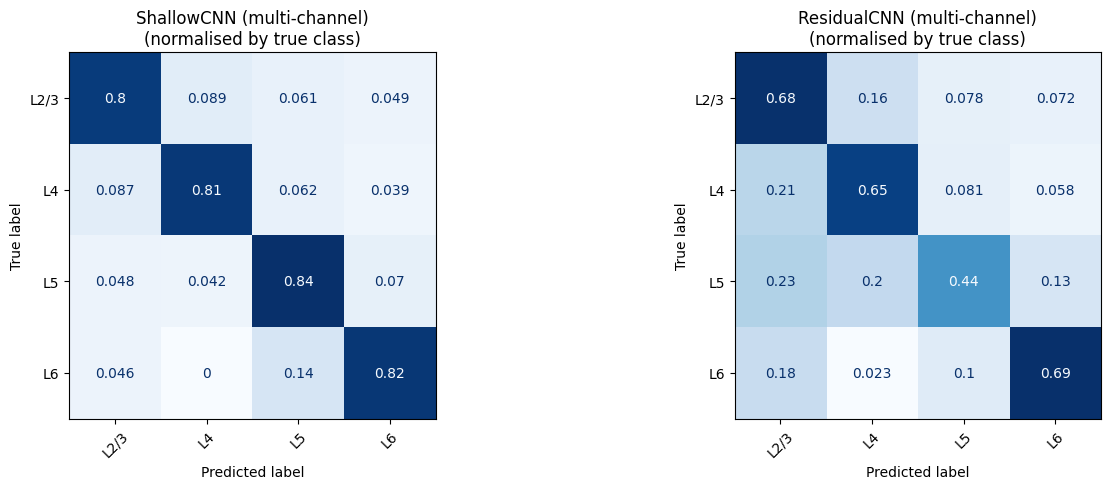

In [30]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (model, name) in zip(axes, [
    (shallow_cnn,  'ShallowCNN (multi-channel)'),
    (residual_cnn, 'ResidualCNN (multi-channel)'),
]):
    y_pred = evaluate(model, test_loader)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=enc.classes_,
        xticks_rotation=45,
        cmap='Blues',
        normalize='true',
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f'{name}\n(normalised by true class)')

plt.tight_layout()
plt.show()

In [31]:
# ── Per-neuron majority-vote ───────────────────────────────────────────────────
from scipy.stats import mode as scipy_mode

def per_neuron_majority_vote(model, X, y, uids):
    loader = make_loader(X, y, shuffle=False)
    preds  = evaluate(model, loader)

    neuron_preds = {}
    neuron_true  = {}
    for uid, pred, true in zip(uids, preds, y):
        neuron_preds.setdefault(uid, []).append(pred)
        neuron_true[uid] = true

    voted_preds, voted_true = [], []
    for uid in neuron_preds:
        majority = scipy_mode(neuron_preds[uid], keepdims=False).mode
        voted_preds.append(majority)
        voted_true.append(neuron_true[uid])

    return np.array(voted_true), np.array(voted_preds)


print('Per-neuron majority-vote results:')
for model, name in [
    (shallow_cnn,  'ShallowCNN'),
    #(residual_cnn, 'ResidualCNN'),
]:
    vt, vp = per_neuron_majority_vote(model, X_test, y_test, uids_test)
    print(f'\n{name}:')
    print(f'  Neurons evaluated: {len(vt)}')
    print(f'  Accuracy:          {accuracy_score(vt, vp):.3f}')
    print(f'  Balanced accuracy: {balanced_accuracy_score(vt, vp):.3f}')
    print(f'  Macro F1:          {f1_score(vt, vp, average="macro"):.3f}')
    print(classification_report(vt, vp, target_names=enc.classes_))

Per-neuron majority-vote results:

ShallowCNN:
  Neurons evaluated: 1637
  Accuracy:          0.814
  Balanced accuracy: 0.818
  Macro F1:          0.771
              precision    recall  f1-score   support

        L2/3       0.89      0.80      0.84       676
          L4       0.85      0.81      0.83       518
          L5       0.78      0.84      0.81       356
          L6       0.48      0.82      0.60        87

    accuracy                           0.81      1637
   macro avg       0.75      0.82      0.77      1637
weighted avg       0.83      0.81      0.82      1637



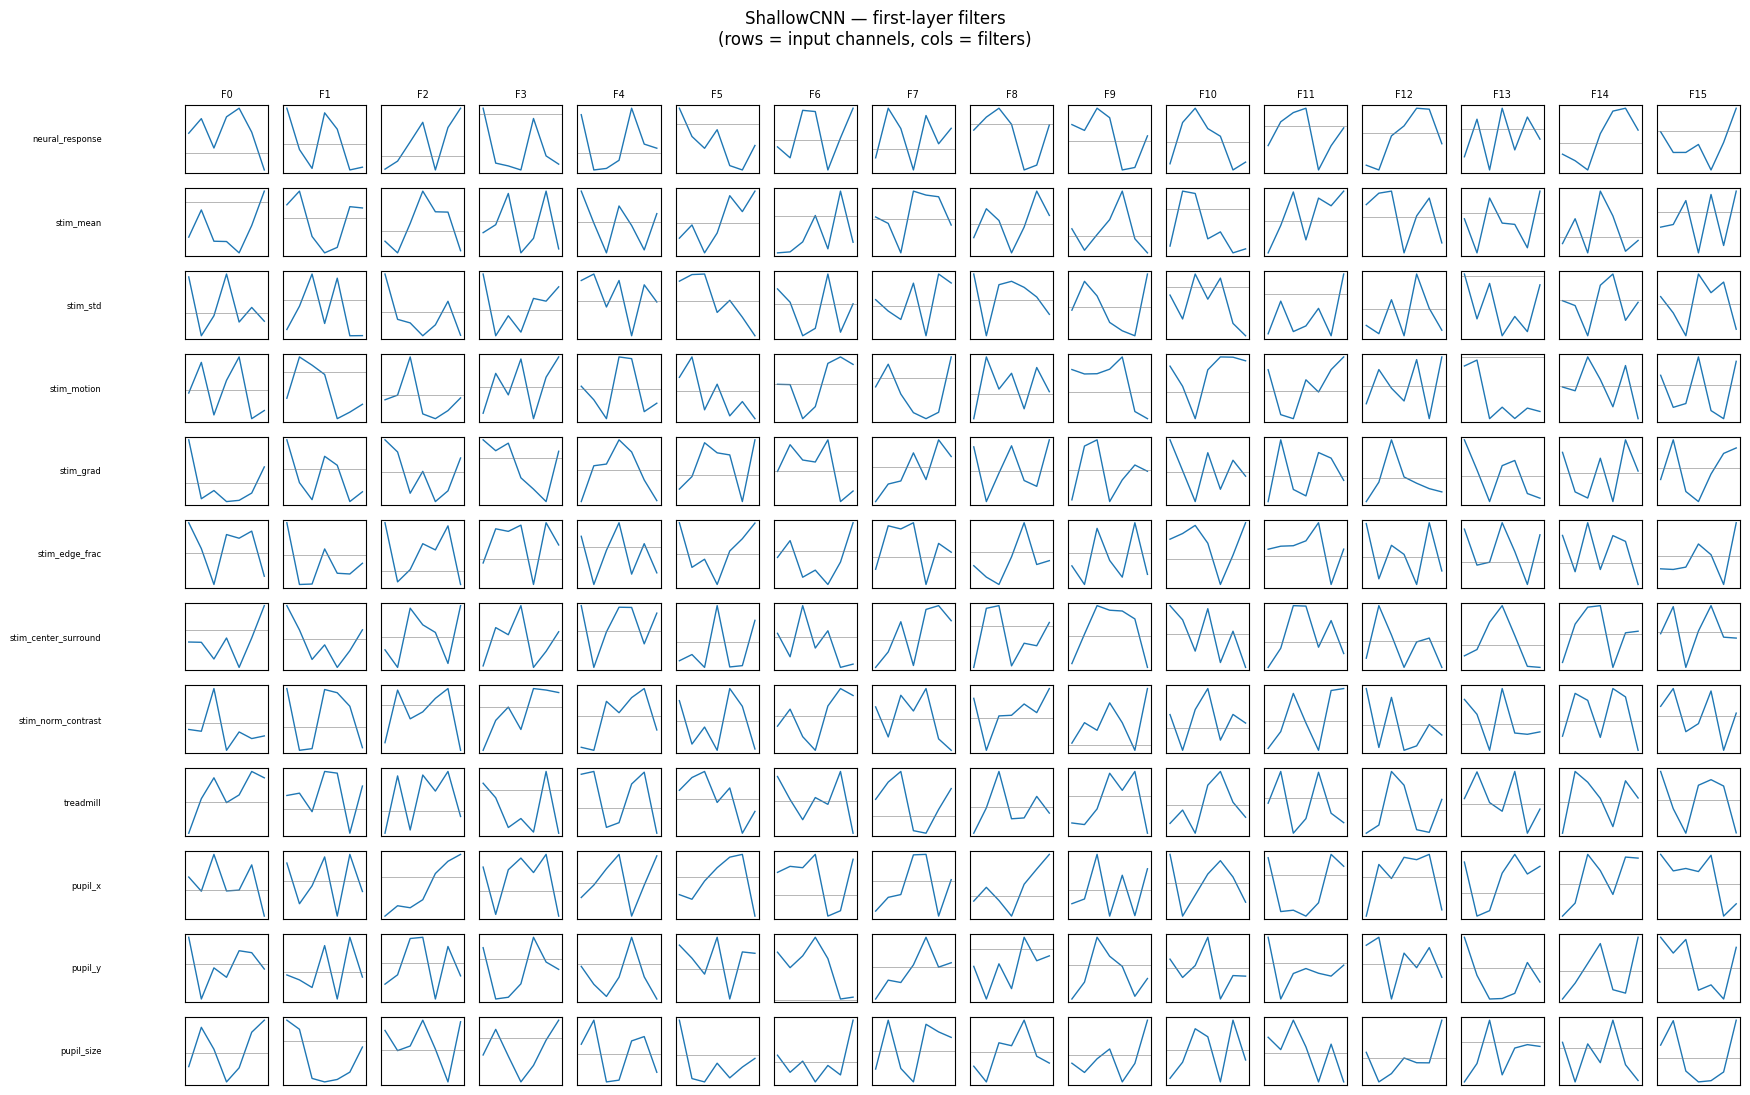

In [32]:
# ── Visualise first-layer filters of ShallowCNN ───────────────────────────────
# Each filter now has shape (N_CHANNELS, kernel_size); plot one row per input channel.
first_conv = shallow_cnn.conv[0]  # Conv1d(N_CHANNELS, 64, kernel_size=7)
filters    = first_conv.weight.detach().cpu().numpy()  # (64, N_CHANNELS, 7)

n_filters_to_show = min(16, filters.shape[0])
fig, axes = plt.subplots(N_CHANNELS, n_filters_to_show,
                          figsize=(n_filters_to_show * 1.1, N_CHANNELS * 0.9))

for ch_idx in range(N_CHANNELS):
    for f_idx in range(n_filters_to_show):
        ax = axes[ch_idx, f_idx]
        ax.plot(filters[f_idx, ch_idx], linewidth=1)
        ax.axhline(0, color='grey', linewidth=0.4)
        ax.set_xticks([])
        ax.set_yticks([])
        if f_idx == 0:
            ax.set_ylabel(CHANNEL_NAMES[ch_idx], fontsize=6, rotation=0,
                          ha='right', va='center', labelpad=60)
        if ch_idx == 0:
            ax.set_title(f'F{f_idx}', fontsize=7)

fig.suptitle('ShallowCNN — first-layer filters\n(rows = input channels, cols = filters)',
             y=1.01)
plt.tight_layout()
plt.show()

## Results & Discussion

### Design rationale

The multi-channel approach treats the full trial as a **12-track time series** and lets the CNN learn which temporal patterns — and which combinations of input channels — are diagnostic of each cortical layer. The key differences with respect to the single-channel notebooks are:

- The first convolutional layer now processes all 12 channels **simultaneously**, so cross-channel interactions (e.g. neural response locked to motion energy, or pupil dilation correlated with response amplitude) can be captured from the very first layer.
- The stimulus channels provide a frame-by-frame "context" alongside the neural trace, reducing ambiguity when two neurons have similar response amplitudes but couple differently to visual drive.
- The behavioural channels (treadmill and pupil) capture arousal state, which is known to modulate both response gain and layer-specific coding.

### What to look for in the results

| Metric | Expectation |
|---|---|
| **Balanced accuracy** | Should exceed the single-channel CNN if stimulus/behaviour channels add discriminative information; chance = 25 % for 4 classes |
| **L2/3 vs L4 confusion** | The hardest pair in all previous attempts; stimulus-coupling channels may help separate them if L4 cells are more driven by low-level visual features |
| **Per-neuron majority vote** | Always higher than trial-level accuracy; the gap reflects how consistent the model is across trials for the same neuron |
| **First-layer filter plot** | Filters should show channel-specific temporal patterns; stimulus channels may specialise for onset/offset transients while the neural channel may learn slow-drift vs burst patterns |

### Limitations

- **Stimulus channel resolution mismatch.** Stimulus features are computed at video-frame rate and linearly resampled to match the neural recording rate. This interpolation discards sub-frame temporal structure and may introduce smoothing artefacts at the resampling boundaries.
- **Pupil tracking quality.** Pupil position and size are sometimes missing or noisy; zero-filling NaN values (the current strategy) effectively treats missing data as zero deviation from the mean, which is a conservative but potentially misleading imputation.
- **Trial-count limit.** Only `MAX_TRIALS_PER_SCAN = 8` trials are used per session/scan to keep runtime manageable. Increasing this would improve signal quality for the coupling channels at the cost of longer collection time.
- **No temporal alignment between stimulus and response.** The neural trace and stimulus feature channels are naively concatenated at the same length. A biologically accurate alignment would account for the ~50–100 ms visual latency of V1 neurons.
- **Validation split is still by neuron, not by scan session.** Different trials from the same neuron are all in the same split, which is correct. However, neurons recorded in the same session share a common neural state (arousal, adaptation), so a session-level split would be stricter.